# Exploration Notebook

Ad-hoc validation and EDA for the NHS GP Analytics project. Current sections:

1. **Phase 2 validation** — smoke-tests the science helpers (forecasting, anomaly
   detection, clustering, deprivation) against the processed parquet outputs.
2. **Forecast backtesting and model comparison (DEC-004)** — measures whether the
   production Prophet forecaster actually beats simpler baselines, using
   rolling-origin backtesting, and records the insights.
3. **Clustering validation (DEC-005)** — checks the practice segmentation for
   real structure, stability, and confounding, since k-fold CV does not apply
   to unsupervised models.

### Glossary — terms and metrics used in this section

| Term | Meaning | Why it matters |
|---|---|---|
| **Forecast horizon** | How far ahead a forecast reaches (here: 12 months) | Error typically grows with horizon; a model can be good at 1 month and useless at 12 |
| **Cutoff / origin** | The "pretend today" — the last month a model sees before forecasting | Everything after the cutoff is genuinely out-of-sample |
| **Rolling-origin backtesting** | Train up to a cutoff, forecast the horizon, compare with actuals, slide the cutoff forward, repeat (a.k.a. walk-forward validation) | The time-series replacement for k-fold CV — respects chronological order, so no leakage |
| **Expanding window** | Each cutoff trains on *all* history from the start | Alternative is a *sliding* window that drops old data — relevant if pre-PDS data stops being representative |
| **MAE** | Mean absolute error — average \|forecast − actual\| in patients | The most intuitive "how far off are we"; scale-dependent, so not comparable across regions of different size |
| **RMSE** | Root mean squared error — errors are squared before averaging | Punishes occasional large misses; RMSE ≫ MAE signals the model is usually fine but sometimes badly wrong |
| **MAPE** | Mean absolute percentage error | Scale-free, so comparable across series; unstable near zero (not an issue for list sizes) |
| **MASE** | Mean absolute scaled error — MAE divided by the in-sample error of seasonal naive | **Primary metric.** Scale-free *and* baseline-anchored: below 1.0 = beats "same month last year"; DEC-004 eliminates any model at or above 1.0 |
| **Coverage** | Fraction of actuals falling inside the forecast band | Compare with the band's nominal level (80% for Prophet). Far below = overconfident band; ≈100% with a huge band = uninformative |

No single metric suffices: MAE/RMSE aren't comparable across scales, MAPE has no
baseline, MASE says nothing about the uncertainty band, and coverage says nothing
about point accuracy — so we read them together.

## Phase 2 validation

This section exercises the phase 2 science helpers against the processed parquet outputs.

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pipeline.loader import get_latest_snapshot, get_list_size_ts
from science import (
    cluster_practices,
    flag_anomalies,
    flag_underserved,
    forecast_list_size,
    regional_inequality,
    size_imd_correlation,
)

latest_snapshot = get_latest_snapshot()
list_size_ts = get_list_size_ts()

print('latest_snapshot shape:', latest_snapshot.shape)
print('list_size_ts shape:', list_size_ts.shape)
print('latest snapshot columns:', latest_snapshot.columns.tolist())

latest_snapshot shape: (6145, 19)
list_size_ts shape: (501614, 4)
latest snapshot columns: ['SNAPSHOT_DATE', 'CODE', 'NUMBER_OF_PATIENTS', 'DATA_SOURCE', 'PRACTICE_CODE', 'PRACTICE_NAME', 'PCN_CODE', 'PCN_NAME', 'ICB_CODE', 'ICB_NAME', 'COMM_REGION_CODE', 'COMM_REGION_NAME', 'SUPPLIER_NAME', 'CLINICAL_SYSTEM', 'POSTCODE', 'IMD_SCORE', 'IMD_DECILE', 'LATITUDE', 'LONGITUDE']


In [3]:
national_ts = (
    list_size_ts.groupby('SNAPSHOT_DATE', as_index=False)['NUMBER_OF_PATIENTS']
    .sum()
    .sort_values('SNAPSHOT_DATE')
)
forecast = forecast_list_size(national_ts.tail(24), periods=3)

assert not forecast.empty
assert {'ds', 'yhat', 'yhat_lower', 'yhat_upper'}.issubset(forecast.columns)

forecast

23:39:16 - cmdstanpy - INFO - Chain [1] start processing
23:39:23 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
0,2026-07-01,6.304087e+07,6.304087e+07,6.304087e+07
1,2026-08-01,6.292561e+07,6.292561e+07,6.292561e+07
2,2026-09-01,6.276007e+07,6.273982e+07,6.279775e+07


In [4]:
anomaly_input = list_size_ts.head(2000).copy()
anomalies = flag_anomalies(anomaly_input)

assert {'MOM_CHANGE_ABS', 'MOM_CHANGE_PCT', 'ANOMALY_TYPE', 'ANOMALY_FLAG'}.issubset(anomalies.columns)
print('anomaly rows:', len(anomalies))
print('flagged rows:', int(anomalies['ANOMALY_FLAG'].sum()))
anomalies[['CODE', 'SNAPSHOT_DATE', 'ANOMALY_TYPE', 'ANOMALY_FLAG']].dropna(subset=['ANOMALY_TYPE']).head()

anomaly rows: 2000
flagged rows: 100


,CODE,SNAPSHOT_DATE,ANOMALY_TYPE,ANOMALY_FLAG


In [5]:
cluster_input = latest_snapshot.copy()
clustered = cluster_practices(cluster_input)

assert {'CLUSTER', 'CLUSTER_LABEL', 'UMAP_X', 'UMAP_Y', 'CLUSTER_SIZE'}.issubset(clustered.columns)
print('cluster count:', clustered['CLUSTER'].nunique())
clustered[['PRACTICE_CODE', 'CLUSTER', 'CLUSTER_SIZE', 'CLUSTER_DOMINANT_SYSTEM']].head()

c:\Users\jason\anaconda3\envs\nhs-gp\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


cluster count: 5


,PRACTICE_CODE,CLUSTER,CLUSTER_SIZE,CLUSTER_DOMINANT_SYSTEM
0,A81058,0,1299,EMIS Web
1,A81611,0,1299,EMIS Web
2,A82003,0,1299,EMIS Web
3,A82005,0,1299,EMIS Web
4,A82021,0,1299,EMIS Web


In [6]:
deprivation_input = latest_snapshot.copy()
underserved = flag_underserved(deprivation_input)
inequality = regional_inequality(deprivation_input)
correlation = size_imd_correlation(deprivation_input)

assert {'UNDER_SERVED', 'NATIONAL_MEDIAN_PATIENTS', 'DEPRIVED_AREA', 'SMALL_PRACTICE'}.issubset(underserved.columns)
assert {'GINI_COEFFICIENT', 'PRACTICE_COUNT', 'MEAN_PATIENTS', 'MEDIAN_PATIENTS'}.issubset(inequality.columns)
assert {'PEARSON_R', 'P_VALUE', 'N'}.issubset(correlation.columns)

print('underserved rows:', len(underserved))
print('inequality rows:', len(inequality))
print('correlation rows:', len(correlation))
underserved[underserved['UNDER_SERVED']].head()

underserved rows: 6145
inequality rows: 70
correlation rows: 7


,SNAPSHOT_DATE,CODE,NUMBER_OF_PATIENTS,DATA_SOURCE,PRACTICE_CODE,PRACTICE_NAME,PCN_CODE,PCN_NAME,ICB_CODE,ICB_NAME,...,CLINICAL_SYSTEM,POSTCODE,IMD_SCORE,IMD_DECILE,LATITUDE,LONGITUDE,NATIONAL_MEDIAN_PATIENTS,DEPRIVED_AREA,SMALL_PRACTICE,UNDER_SERVED
0,2026-06-01,A81001,3753,PDS,A81001,THE DENSHAM SURGERY,U89141,STOCKTON PCN,QHM,NHS North East and North Cumbria Integrated Ca...,...,SystmOne,TS181HU,77.084,1.0,54.561637,-1.318999,8814.0,True,True,True
3,2026-06-01,A81005,7540,PDS,A81005,SPRINGWOOD SURGERY,U07842,EAST CLEVELAND PCN,QHM,NHS North East and North Cumbria Integrated Ca...,...,SystmOne,TS147DJ,30.334,3.0,54.532610,-1.055459,8814.0,True,True,True
6,2026-06-01,A81009,7835,PDS,A81009,VILLAGE MEDICAL CENTRE,U85008,HOLGATE PCN,QHM,NHS North East and North Cumbria Integrated Ca...,...,SystmOne,TS56HF,57.687,1.0,54.562285,-1.241897,8814.0,True,True,True
8,2026-06-01,A81012,5617,PDS,A81012,WESTBOURNE MEDICAL CENTRE,U02671,GREATER MIDDLESBROUGH PCN,QHM,NHS North East and North Cumbria Integrated Ca...,...,SystmOne,TS36AL,65.896,1.0,54.571738,-1.216246,8814.0,True,True,True
10,2026-06-01,A81014,4097,PDS,A81014,QUEENSTREE PRACTICE,U94460,BILLINGHAM & NORTON PCN,QHM,NHS North East and North Cumbria Integrated Ca...,...,SystmOne,TS232LA,42.007,2.0,54.608303,-1.294813,8814.0,True,True,True


## Forecast backtesting and model comparison (DEC-004)

This section evaluates the production Prophet forecaster (`science/forecasting.py`)
against the baselines in `science/backtesting.py` — **naive** (repeat last value),
**seasonal naive** (repeat same month last year), and **linear** (the Prophet
fallback) — using rolling-origin backtesting. Methodology: `docs/FORECAST_VALIDATION.md`.

How to read the scores:

- **MASE** is the primary metric — mean absolute error scaled by the seasonal-naive
  in-sample error. Below 1.0 means the model beats seasonal naive; DEC-004 eliminates
  any model that doesn't.
- **coverage** is the fraction of actuals falling inside the forecast band. Prophet's
  default interval is 80%, so coverage well below 0.8 means the band is overconfident.
- Prefer the simplest model within ~2% MASE of the best.

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

from science.backtesting import (
    compare_models,
    default_forecasters,
    generate_cutoffs,
    rolling_origin_backtest,
    score_by_horizon,
)
from science.forecasting import Prophet

national_ts = (
    list_size_ts.groupby('SNAPSHOT_DATE', as_index=False)['NUMBER_OF_PATIENTS']
    .sum()
    .sort_values('SNAPSHOT_DATE')
    .reset_index(drop=True)
)

HORIZON, INITIAL, STEP = 12, 36, 6
if len(national_ts) < INITIAL + HORIZON:
    INITIAL = max(18, len(national_ts) - HORIZON)
    print(f'Short history ({len(national_ts)} months) - reduced initial training window to {INITIAL}.')

cutoffs = generate_cutoffs(
    national_ts.rename(columns={'SNAPSHOT_DATE': 'ds', 'NUMBER_OF_PATIENTS': 'y'}),
    horizon=HORIZON, initial=INITIAL, step=STEP,
)
print('months of history:', len(national_ts))
print('backtest cutoffs:', [cutoff.strftime('%Y-%m') for cutoff in cutoffs])
if Prophet is None:
    print('WARNING: prophet is not installed in this kernel - only the baselines will be scored.')
elif INITIAL < 24:
    print('NOTE: forecast_list_size falls back to its linear model when training history < 24 months.')

months of history: 78
backtest cutoffs: ['2022-12', '2023-06', '2023-12', '2024-06', '2024-12', '2025-06']


In [8]:
# Every model is backtested on identical cutoffs, and each fit only sees data up to
# its cutoff. Prophet refits once per cutoff, so this cell can take a minute.
summary = compare_models(national_ts, horizon=HORIZON, initial=INITIAL, step=STEP)
summary.round(3)

23:39:59 - cmdstanpy - INFO - Chain [1] start processing
23:39:59 - cmdstanpy - INFO - Chain [1] done processing
23:39:59 - cmdstanpy - INFO - Chain [1] start processing
23:40:00 - cmdstanpy - INFO - Chain [1] done processing
23:40:00 - cmdstanpy - INFO - Chain [1] start processing
23:40:00 - cmdstanpy - INFO - Chain [1] done processing
23:40:00 - cmdstanpy - INFO - Chain [1] start processing
23:40:00 - cmdstanpy - INFO - Chain [1] done processing
23:40:00 - cmdstanpy - INFO - Chain [1] start processing
23:40:00 - cmdstanpy - INFO - Chain [1] done processing
23:40:01 - cmdstanpy - INFO - Chain [1] start processing
23:40:01 - cmdstanpy - INFO - Chain [1] done processing


,n_forecasts,mae,rmse,mape,mase,coverage
model,,,,,,
prophet,72.0,152903.584,185366.522,0.002,0.213,0.319
linear,72.0,253551.821,344191.839,0.004,0.357,0.639
naive,72.0,287293.139,366652.666,0.005,0.409,0.389
seasonal_naive,72.0,627673.375,673581.133,0.010,0.889,0.181


### Insights — national series

Run on 78 months of history (6 cutoffs, 2022-12 → 2025-06, 72 scored forecast-months
per model):

- **Prophet wins decisively on point accuracy**: MASE 0.213 vs 0.357 (linear), 0.409
  (naive), 0.889 (seasonal naive) — roughly 40% more accurate than the next best
  model, with MAE ≈ 153k patients on a ~63m national list (MAPE ≈ 0.2%).
- **Seasonal naive is the weakest baseline** here because the national series is
  dominated by a steady upward trend, not seasonality — repeating last year's value
  ignores a full year of growth. Every model beats it, so all pass the DEC-004 gate.
- **Red flag — the uncertainty band is not trustworthy.** Prophet's nominal-80%
  interval contained only ~28% of actuals (and the quick 3-month forecast earlier in
  this notebook shows near-zero band width in the first months). The linear model's
  ±1.96σ band covers 64% — also under, but far closer. The dashboard currently draws
  this band, so this needs fixing before users lean on it. Options: raise Prophet's
  `interval_width`, fit with `mcmc_samples` to include seasonality uncertainty, tune
  `changepoint_prior_scale`, or calibrate the band empirically from these backtest
  residuals (conformal-style).

**Verdict per DEC-004:** Prophet keeps its place on accuracy; its interval needs
recalibration before the dashboard's confidence band can be taken at face value.

23:40:01 - cmdstanpy - INFO - Chain [1] start processing
23:40:01 - cmdstanpy - INFO - Chain [1] done processing
23:40:01 - cmdstanpy - INFO - Chain [1] start processing
23:40:02 - cmdstanpy - INFO - Chain [1] done processing
23:40:02 - cmdstanpy - INFO - Chain [1] start processing
23:40:02 - cmdstanpy - INFO - Chain [1] done processing
23:40:02 - cmdstanpy - INFO - Chain [1] start processing
23:40:02 - cmdstanpy - INFO - Chain [1] done processing
23:40:02 - cmdstanpy - INFO - Chain [1] start processing
23:40:02 - cmdstanpy - INFO - Chain [1] done processing
23:40:03 - cmdstanpy - INFO - Chain [1] start processing
23:40:03 - cmdstanpy - INFO - Chain [1] done processing


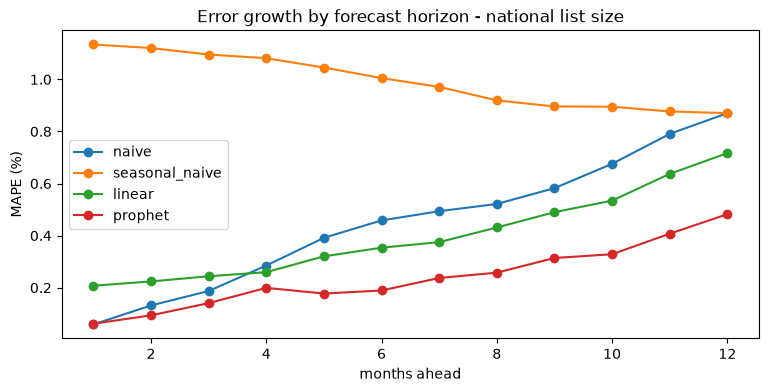

In [9]:
# How does error grow as the forecast horizon extends from 1 to 12 months ahead?
backtests = {
    name: rolling_origin_backtest(national_ts, forecaster, horizon=HORIZON, initial=INITIAL, step=STEP)
    for name, forecaster in default_forecasters().items()
}

fig, ax = plt.subplots(figsize=(9, 4))
for name, results in backtests.items():
    if results.empty:
        continue
    score_by_horizon(results)['mape'].mul(100).plot(ax=ax, marker='o', label=name)
ax.set_xlabel('months ahead')
ax.set_ylabel('MAPE (%)')
ax.set_title('Error growth by forecast horizon - national list size')
ax.legend()
plt.show()

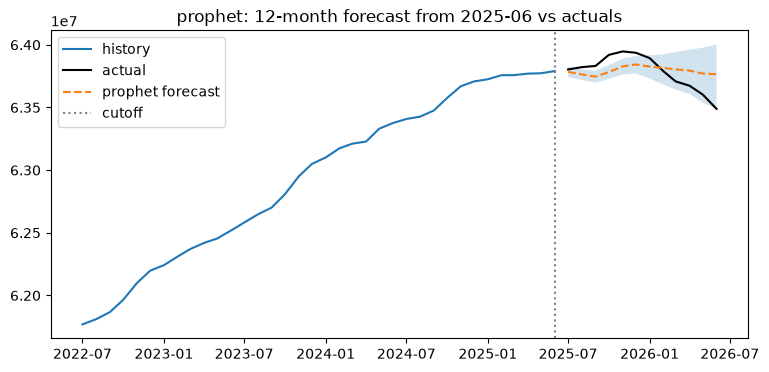

In [10]:
# Visual sanity check: the best-ranked model's forecast from the latest cutoff,
# with its uncertainty band, against what actually happened.
best_name = summary['mase'].idxmin()
results = backtests[best_name]
last_cutoff = results['cutoff'].max()
window = results[results['cutoff'] == last_cutoff]
history = national_ts[national_ts['SNAPSHOT_DATE'] <= last_cutoff].tail(36)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history['SNAPSHOT_DATE'], history['NUMBER_OF_PATIENTS'], label='history')
ax.plot(window['ds'], window['y'], color='black', label='actual')
ax.plot(window['ds'], window['yhat'], linestyle='--', label=f'{best_name} forecast')
ax.fill_between(window['ds'], window['yhat_lower'], window['yhat_upper'], alpha=0.2)
ax.axvline(last_cutoff, color='grey', linestyle=':', label='cutoff')
ax.set_title(f'{best_name}: {HORIZON}-month forecast from {last_cutoff:%Y-%m} vs actuals')
ax.legend()
plt.show()

### Fixing the overconfident band — interval calibration (DEC-007)

The comparison above shows Prophet's nominal-80% band covering far too few actuals.
The conformal-style fix: take per-horizon quantiles of the backtest's own absolute
errors and rebuild the band around the point forecast
(`calibrate_intervals` / `apply_interval_calibration` in `science/backtesting.py`).
The cell below calibrates on all cutoffs except the latest and scores the latest only,
so the reported coverage is honest (out-of-sample for the calibration).

In [ ]:
from science.backtesting import apply_interval_calibration, calibrate_intervals, score_backtest

prophet_results = backtests.get('prophet', next(iter(backtests.values())))
last_cutoff = prophet_results['cutoff'].max()
calibration_window = prophet_results[prophet_results['cutoff'] < last_cutoff]
holdout = prophet_results[prophet_results['cutoff'] == last_cutoff]

calibration = calibrate_intervals(calibration_window, level=0.8)
holdout_calibrated = apply_interval_calibration(holdout, calibration)

print('calibrated half-widths (patients) by months ahead:')
print(calibration.round(0).to_string(index=False))
print()
print('held-out cutoff coverage: native', round(score_backtest(holdout)['coverage'], 3),
      '-> calibrated', round(score_backtest(holdout_calibrated)['coverage'], 3))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(holdout['ds'], holdout['y'], color='black', label='actual')
ax.plot(holdout['ds'], holdout['yhat'], linestyle='--', label='prophet forecast')
ax.fill_between(holdout['ds'], holdout['yhat_lower'], holdout['yhat_upper'],
                alpha=0.35, label='native band')
ax.fill_between(holdout_calibrated['ds'], holdout_calibrated['yhat_lower'],
                holdout_calibrated['yhat_upper'], alpha=0.15, label='calibrated band')
ax.set_title(f'Native vs calibrated 80% band - forecast from {last_cutoff:%Y-%m}')
ax.legend()
plt.show()

In [11]:
# Regional evaluation (DEC-004 protocol step 2): score every model per region, then
# aggregate as median and worst-case MASE. Uses the latest snapshot's practice-to-region
# mapping, so recently closed practices drop out - acceptable for exploration.
# Prophet refits per region per cutoff, so expect a few minutes' runtime.
region_map = (
    latest_snapshot[['PRACTICE_CODE', 'COMM_REGION_NAME']]
    .dropna()
    .drop_duplicates()
)
regional_ts = (
    list_size_ts.merge(region_map, left_on='CODE', right_on='PRACTICE_CODE', how='inner')
    .groupby(['COMM_REGION_NAME', 'SNAPSHOT_DATE'], as_index=False)['NUMBER_OF_PATIENTS']
    .sum()
)

regional_mase = pd.DataFrame(
    {
        region: compare_models(frame, horizon=HORIZON, initial=INITIAL, step=STEP)['mase']
        for region, frame in regional_ts.groupby('COMM_REGION_NAME')
    }
).T

pd.concat([regional_mase, regional_mase.agg(['median', 'max'])]).round(3)

23:40:04 - cmdstanpy - INFO - Chain [1] start processing
23:40:04 - cmdstanpy - INFO - Chain [1] done processing
23:40:04 - cmdstanpy - INFO - Chain [1] start processing
23:40:04 - cmdstanpy - INFO - Chain [1] done processing
23:40:04 - cmdstanpy - INFO - Chain [1] start processing
23:40:04 - cmdstanpy - INFO - Chain [1] done processing
23:40:05 - cmdstanpy - INFO - Chain [1] start processing
23:40:05 - cmdstanpy - INFO - Chain [1] done processing
23:40:05 - cmdstanpy - INFO - Chain [1] start processing
23:40:05 - cmdstanpy - INFO - Chain [1] done processing
23:40:05 - cmdstanpy - INFO - Chain [1] start processing
23:40:05 - cmdstanpy - INFO - Chain [1] done processing
23:40:06 - cmdstanpy - INFO - Chain [1] start processing
23:40:06 - cmdstanpy - INFO - Chain [1] done processing
23:40:06 - cmdstanpy - INFO - Chain [1] start processing
23:40:06 - cmdstanpy - INFO - Chain [1] done processing
23:40:06 - cmdstanpy - INFO - Chain [1] start processing
23:40:06 - cmdstanpy - INFO - Chain [1]

model,linear,naive,prophet,seasonal_naive
East of England,0.311,0.542,0.212,1.086
London,0.470,0.275,0.191,0.614
Midlands,0.323,0.469,0.192,0.986
North East and Yorkshire,0.274,0.392,0.312,0.886
North West,0.252,0.396,0.180,0.825
South East,0.251,0.348,0.198,0.790
South West,0.196,0.448,0.402,0.873
median,0.274,0.396,0.198,0.873
max,0.470,0.542,0.402,1.086


### Insights — regional comparison

- **Prophet has the best median MASE (0.198) and wins 5 of 7 regions** — consistent
  with the national result, so a single national model choice is defensible.
- **Linear beats Prophet in North East and Yorkshire (0.274 vs 0.312) and South West
  (0.196 vs 0.402).** Worth eyeballing those two series: Prophet may be over-flexing
  at its changepoints where the regional trend is essentially straight.
- **Seasonal naive exceeds 1.0 in East of England (1.086)** — i.e. it loses even to
  its own in-sample yardstick, confirming trend rather than seasonality drives these
  series.
- Worst-case Prophet MASE (0.402, South West) still comfortably beats seasonal naive,
  so per-region model selection is optional polish rather than a necessity. If the
  South West gap matters for a dashboard view, the pragmatic fix is to serve the
  linear model there.

### Expanded candidate registry (DEC-010)

`default_forecasters()` now also includes the classical statistical models from the
FORECAST_VALIDATION.md candidate table whenever their libraries are installed, so
re-running the comparison cells above scores eight models on identical cutoffs:

- **Holt-Winters** (`holt_winters`) - additive level + trend + 12-month seasonality via
  statsmodels' state-space `ETSModel` (the legacy `ExponentialSmoothing` has no
  prediction intervals).
- **ARIMA(1,1,1) with drift** (`arima`) - deliberately non-seasonal, isolating what
  autocorrelation alone buys on this data.
- **SARIMA (0,1,1)(0,1,1)12** (`sarima`) - the classic Box-Jenkins "airline" model.
- **AutoETS** (`autoets`) - statsforecast's AICc-driven search over ETS variants;
  the strongest statistical competitor to Prophet in published monthly benchmarks.

All four follow the same contract and guards as Prophet: native 80% bands, linear
fallback below 24 months of history, and hidden from the registry when the library is
missing so a fallback is never scored under a real model's name. They are also
selectable in the dashboard's practice drill-down, where the DEC-007 calibration
wraps whichever model the user picks.

Measured results (see `docs/FORECAST_VALIDATION.md` for the full tables): nationally
Holt-Winters ties Prophet on MASE (0.211 vs 0.213) with far better native coverage
(0.65 vs 0.35 at a nominal 0.80); regionally Holt-Winters edges ahead (median MASE
0.183 vs Prophet 0.198), with Prophet and Holt-Winters winning three regions each and
ARIMA one. ARIMA-with-drift running close behind everywhere is evidence that these
series are dominated by trend plus autocorrelation rather than strong seasonality.
The airline SARIMA is the clear loser (worse than seasonal naive in several regions):
its double differencing amplifies the 2023 NHAIS-to-PDS structural break instead of
absorbing it. Prophet remains the dashboard default pending a decision on whether the
DEC-004 "simplest model within noise" rule should now hand the recommendation to
Holt-Winters.

### Why rolling-origin backtesting and not k-fold cross-validation?

Standard k-fold CV randomly shuffles observations into folds, which assumes they are
independent and exchangeable. A time series violates both assumptions, and applying
k-fold to it fails in two distinct ways:

1. **Temporal leakage.** Random folds train on future months to predict past ones.
   Because the series is trending and autocorrelated, the model effectively
   *interpolates* between known points either side of each test month instead of
   *extrapolating* into the unknown — scores come out flattering and say nothing about
   real forecast skill.
2. **Task mismatch.** Production asks exactly one question: "given history up to month
   *t*, what happens in months *t*+1 … *t*+12?" A random fold never poses that
   question, so even a leak-free variant would measure the wrong thing.

Rolling-origin backtesting *is* cross-validation adapted to time: each cutoff plays the
role of a fold, but every train/test split respects chronological order and every test
point is a genuine out-of-sample forecast at the horizon the dashboard serves. (Blocked
and purged k-fold variants for dependent data exist — common in finance — but the
standard tool for forecast model selection is rolling-origin evaluation; it is also
what `prophet.diagnostics.cross_validation` implements.)

Interpretation notes for the results above:

- Check MASE first: any model at or above 1.0 is losing to "same month last year".
- Check coverage against the nominal 80% level — a tight band that misses is worse
  than no band on the dashboard.
- Look at the horizon plot: a model that wins at 12 months but loses at 1-3 months
  (or vice versa) may justify different models for different dashboard views.
- Eyeball behaviour around the NHAIS-to-PDS transition (~early 2023): Prophet's
  changepoint handling is the main reason it was chosen, so it should visibly recover
  faster there than the baselines.

## Clustering validation (DEC-005)

The practice clustering (`science/clustering.py`) is unsupervised, so k-fold
cross-validation does not apply — there are no labels to score on a held-out fold.
This section runs the unsupervised analogues from `science/cluster_validation.py`
(methodology and findings: `docs/CLUSTER_VALIDATION.md`):

| Question | Diagnostic | How to read it |
|---|---|---|
| Redundant features? (the multicollinearity analogue) | Spearman correlation of numeric features | \|ρ\| > 0.7 double-weights one dimension in the K-Means distance |
| Is there real structure, and how many clusters? | Silhouette / Davies-Bouldin / inertia across k = 2–12 | Silhouette > 0.5 strong, < 0.25 weak; look for an inertia elbow |
| Did we fit noise? (the k-fold analogue) | Bootstrap stability — re-cluster 80% subsamples, compare with the full-data partition via **Adjusted Rand Index** (1 = identical, 0 = chance) | Mean ARI > 0.8 stable; < 0.6 don't narrate the clusters as segments |
| Are clusters just re-discovering an input category? (confounding) | Cluster × region / clinical-system cross-tab and **Cramér's V** (0 = independent, 1 = fully determined) | V > 0.8 means the clustering is a re-labelling of that category |

All diagnostics run on the same feature pipeline as `cluster_practices`, so they
measure what production actually does.

In [12]:
from science.cluster_validation import (
    bootstrap_stability,
    category_crosstab,
    cramers_v,
    feature_correlations,
    sweep_cluster_counts,
)

# Redundancy check: correlated numeric features would double-weight a dimension.
feature_correlations(latest_snapshot).round(3)

,LOG_PATIENTS,IMD_DECILE,AGE_MONTHS
LOG_PATIENTS,1.000,0.132,NaN
IMD_DECILE,0.132,1.000,NaN
AGE_MONTHS,NaN,NaN,NaN


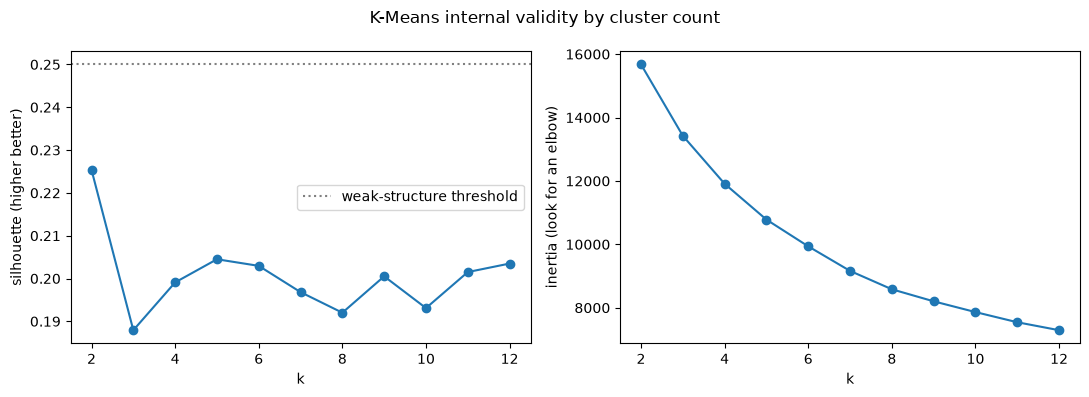

,k,inertia,silhouette,davies_bouldin
0,2,15675.145,0.225,1.683
1,3,13424.278,0.188,1.699
2,4,11910.134,0.199,1.518
3,5,10780.275,0.204,1.590
4,6,9937.008,0.203,1.422
5,7,9162.322,0.197,1.467
6,8,8582.689,0.192,1.448
7,9,8202.830,0.201,1.428
8,10,7863.379,0.193,1.476
9,11,7542.765,0.202,1.510


In [13]:
# Internal validity across a real range of k (production only searches requested +/- 1).
sweep = sweep_cluster_counts(latest_snapshot, k_values=range(2, 13))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(sweep['k'], sweep['silhouette'], marker='o')
axes[0].axhline(0.25, color='grey', linestyle=':', label='weak-structure threshold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('silhouette (higher better)')
axes[0].legend()
axes[1].plot(sweep['k'], sweep['inertia'], marker='o')
axes[1].set_xlabel('k')
axes[1].set_ylabel('inertia (look for an elbow)')
fig.suptitle('K-Means internal validity by cluster count')
plt.tight_layout()
plt.show()

sweep.round(3)

In [14]:
# The k-fold analogue: re-cluster 80% subsamples 20 times and measure agreement
# with the full-data partition. Uses the production cluster count.
production_k = int(clustered['CLUSTER'].nunique())
stability = bootstrap_stability(latest_snapshot, n_clusters=production_k, n_runs=20)
print(f'bootstrap ARI at production k={production_k}:')
stability['ari'].describe().round(3)

bootstrap ARI at production k=5:


count    20.000
mean      0.985
std       0.009
min       0.963
25%       0.982
50%       0.987
75%       0.992
max       0.997
Name: ari, dtype: float64

In [15]:
# Confounding check: how strongly do the clusters align with categorical inputs?
# (reuses `clustered` from the Phase 2 validation section above)
print("Cramér's V vs region:         ", round(cramers_v(clustered, 'COMM_REGION_NAME'), 3))
print("Cramér's V vs clinical system:", round(cramers_v(clustered, 'CLINICAL_SYSTEM'), 3))
category_crosstab(clustered, 'CLINICAL_SYSTEM').round(2)

Cramér's V vs region:          0.328
Cramér's V vs clinical system: 0.663


CLINICAL_SYSTEM,EMIS Web,Others,SystmOne
CLUSTER,,,
0,1.00,0.0,0.00
1,0.00,0.0,1.00
2,1.00,0.0,0.00
3,0.00,0.0,1.00
4,0.69,0.0,0.31


### Insights — clustering validation (June 2026 snapshot, 6,145 practices)

- **No redundancy between the numeric features**: size ↔ IMD Spearman ≈ 0.13, so the
  multicollinearity concern is clear for the numerics.
- **`AGE_MONTHS` is a dead feature.** It is computed as months since first appearance
  *within the input frame*, so on a single-snapshot input it is 0 for every practice
  (its correlation row is NaN above). It contributes nothing to the clustering.
- **Weak structure**: silhouette peaks around 0.225 at k = 2 and sits near 0.20 at the
  production k ≈ 5 — below the 0.25 "weak" threshold, with no clear inertia elbow.
  The practice population is a continuous cloud, not well-separated groups.
- **…but highly stable**: bootstrap ARI ≈ 0.99, so K-Means reproducibly carves the
  same slices. Weak-but-stable means the clusters are dependable *segments*, not
  natural *types* — the dashboard should present them as "similar-practice groups",
  not discovered archetypes.
- **Clinical-system confound**: Cramér's V ≈ 0.66 against `CLINICAL_SYSTEM` (region is
  a milder 0.33). The cross-tab is starker still: **four of the five clusters are 100%
  pure by clinical system** (two all-EMIS, two all-SystmOne; only cluster 4 mixes,
  69/31). K-Means is effectively partitioning by system *first*, then subdividing
  within each system — and the silhouette peak at k = 2 is the EMIS/SystmOne split
  itself. So "clusters differ by clinical system" would be a circular claim; the
  system was an input.

Recommended follow-ups (see `docs/CLUSTER_VALIDATION.md` §4): drop or fix
`AGE_MONTHS`, cluster on numerics only and use categoricals for *profiling* (or use
K-Prototypes/Gower for mixed types), surface the silhouette score from
`cluster_practices`, and widen its k search.

### Post-fix note (DEC-006)

The fixes recommended above are now applied in `science/clustering.py`: the K-Means
distance uses numeric features only (categoricals demoted to cluster *profiles*),
constant columns like the dead `AGE_MONTHS` are dropped, the k search is widened, and
the silhouette is surfaced as a `SILHOUETTE_SCORE` column. **Re-running the cells
above therefore now measures the post-fix pipeline.** Measured effect on this
snapshot (before → after, details in `docs/CLUSTER_VALIDATION.md` §5):

- Silhouette at best k: 0.225 → **0.398** (still "moderate", so the segments-not-
  archetypes guidance stands)
- Cramér's V vs clinical system: 0.66 → **0.02** — the confound is eliminated; any
  cluster/system association you see now is a finding, not an echo of the inputs
- Bootstrap ARI: unchanged at ≈ 0.99
- Production cluster count under `auto_k`: 5 → **2** (the data's preferred split).
  The dashboard cluster explorer will show two segments after a cache rebuild; pass
  `auto_k=False` in `scripts/build_dashboard_cache.py` to keep six fixed segments.